# 04 – Quantile Regression Forest (QRF) Modelling

Reproduces Section 4.4 and 5.2:
- Train QRF models (one per LiDAR structural metric) using SAR and
  Sentinel-2 composites as predictors
- 10-fold spatial cross-validation (Section 4.4.1)
- Accuracy assessment: R², RMSE, bias (Table 3 equivalent)
- Variable importance (Figure 12 equivalent)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from src import config
from src.lidar_metrics import METRIC_NAMES

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from quantile_forest import RandomForestQuantileRegressor
import joblib

## 4.1 Load training table

In [2]:
df = pd.read_parquet(config.TRAINING_TABLE)
print(f"Training samples: {len(df):,}")
print(df.head())

Training samples: 289
        GFP        PAI     stdev     p5    p10    p25    p50    p75     p90  \
0  0.001434  13.094921  0.617406  0.064  0.091  0.142  0.227  0.371  0.5920   
1  0.001191  13.466060  0.629272  0.061  0.089  0.163  0.342  0.616  1.5352   
2  0.001068  13.683343  0.149008  0.041  0.053  0.079  0.115  0.160  0.2220   
3  0.000981  13.853385  0.058503  0.047  0.060  0.087  0.122  0.174  0.2120   
4  0.000753  14.382106  1.358564  0.053  0.074  0.135  0.245  0.525  3.2200   

       p95  ...     s2_blue     s2_green       s2_red  s2_red_edge_1  \
0  1.01905  ...  583.356750   791.003113  1135.858032    1460.598267   
1  2.03300  ...  632.628479   904.311035  1423.588257    1750.410645   
2  0.25600  ...  784.466553  1241.780396  2005.296143    2433.174316   
3  0.23300  ...  876.171387  1425.651367  2331.260498    2547.196777   
4  4.21555  ...  695.820801  1086.969238  1714.555786    2063.827637   

   s2_red_edge_2  s2_red_edge_3     s2_nir_1     s2_nir_2    s2_swir_2

In [3]:
# Define predictor columns (all SAR + S2 composite columns)
predictor_cols = (
    [c for c in df.columns if c.startswith('SAR_')]
    + [c for c in df.columns if c.startswith('s2_')]
)
print(f"Predictors ({len(predictor_cols)}): {predictor_cols}")

Predictors (13): ['SAR_VV_db', 'SAR_VH_db', 'SAR_VVVH_ratio_db', 's2_blue', 's2_green', 's2_red', 's2_red_edge_1', 's2_red_edge_2', 's2_red_edge_3', 's2_nir_1', 's2_nir_2', 's2_swir_2', 's2_swir_3']


## 4.2 Define target metrics to model

In [4]:
# Reproduce Table 3: model all 23 structural metrics
# For quick testing use a subset:
# TARGET_METRICS = ['GFP', 'PAI', 'stdev', 'p50']
TARGET_METRICS = METRIC_NAMES

## 4.3 10-fold spatial cross-validation + QRF training

In [5]:
N_FOLDS = 10
QRF_PARAMS = dict(
    n_estimators=500,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
QUANTILES = [0.1, 0.5, 0.9]

results = {}   # metric → {'r2', 'rmse', 'bias', 'pred', 'obs', 'model'}
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X = df[predictor_cols].values
coords = df[['x', 'y']].values

for metric in TARGET_METRICS:
    y = df[metric].values
    valid = ~np.isnan(y)
    X_v, y_v = X[valid], y[valid]

    pred_median = np.full(y_v.shape[0], np.nan)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_v)):
        model = RandomForestQuantileRegressor(**QRF_PARAMS)
        model.fit(X_v[train_idx], y_v[train_idx])
        pred_median[test_idx] = model.predict(X_v[test_idx], quantiles=0.5)

    r2 = r2_score(y_v, pred_median)
    rmse = np.sqrt(mean_squared_error(y_v, pred_median))
    bias = np.mean(pred_median - y_v)

    # Final model trained on all data
    final_model = RandomForestQuantileRegressor(**QRF_PARAMS)
    final_model.fit(X_v, y_v)

    results[metric] = {
        'r2': r2, 'rmse': rmse, 'bias': bias,
        'pred': pred_median, 'obs': y_v, 'model': final_model,
    }
    print(f"{metric:20s}  R²={r2:.3f}  RMSE={rmse:.4f}  bias={bias:+.4f}")

GFP                   R²=0.089  RMSE=0.0003  bias=-0.0000
PAI                   R²=0.117  RMSE=0.5429  bias=+0.0161
stdev                 R²=0.197  RMSE=0.5774  bias=-0.0941
p5                    R²=0.315  RMSE=0.0166  bias=-0.0012
p10                   R²=0.307  RMSE=0.0260  bias=-0.0022
p25                   R²=0.310  RMSE=0.0535  bias=-0.0062
p50                   R²=0.369  RMSE=0.1148  bias=-0.0144
p75                   R²=0.302  RMSE=0.3873  bias=-0.0652
p90                   R²=0.103  RMSE=1.4405  bias=-0.3764
p95                   R²=0.150  RMSE=1.9067  bias=-0.4053
p98                   R²=0.200  RMSE=2.2854  bias=-0.3163
dens_0_1m             R²=0.340  RMSE=0.0809  bias=+0.0093
dens_1_2m             R²=0.316  RMSE=0.0395  bias=-0.0071
dens_2_3m             R²=0.282  RMSE=0.0218  bias=-0.0039
dens_3_4m             R²=0.044  RMSE=0.0156  bias=-0.0036
dens_4_5m             R²=-0.004  RMSE=0.0111  bias=-0.0034
dens_5_10m            R²=-0.017  RMSE=0.0328  bias=-0.0105
dens_10_15m 

## 4.4 Accuracy summary table (Table 3 equivalent)

In [6]:
summary = pd.DataFrame({
    m: {'R²': v['r2'], 'RMSE': v['rmse'], 'Bias': v['bias']}
    for m, v in results.items()
}).T.round(4)
summary.index.name = 'Metric'
summary = summary.sort_values('R²', ascending=False)
print(summary.to_string())
summary.to_csv(config.OUTPUT_DIR / 'table_accuracy_summary.csv')

                 R²    RMSE    Bias
Metric                             
dens_20_25m  1.0000  0.0000  0.0000
dens_15_20m  1.0000  0.0000  0.0000
p50          0.3695  0.1148 -0.0144
dens_0_1m    0.3404  0.0809  0.0093
dens_>1m     0.3365  0.0812 -0.0095
dens_1_2m    0.3156  0.0395 -0.0071
p5           0.3153  0.0166 -0.0012
p25          0.3099  0.0535 -0.0062
p10          0.3066  0.0260 -0.0022
p75          0.3022  0.3873 -0.0652
dens_2_3m    0.2825  0.0218 -0.0039
dens_>2m     0.2335  0.0596 -0.0116
p98          0.2002  2.2854 -0.3163
stdev        0.1971  0.5774 -0.0941
p95          0.1502  1.9067 -0.4053
PAI          0.1174  0.5429  0.0161
p90          0.1028  1.4405 -0.3764
dens_total   0.0900  0.0003  0.0000
GFP          0.0890  0.0003 -0.0000
dens_3_4m    0.0443  0.0156 -0.0036
dens_4_5m   -0.0044  0.0111 -0.0034
dens_5_10m  -0.0172  0.0328 -0.0105
dens_10_15m -0.0376  0.0028 -0.0005


## 4.5 Observed vs predicted scatter (Figure 11 equivalent)

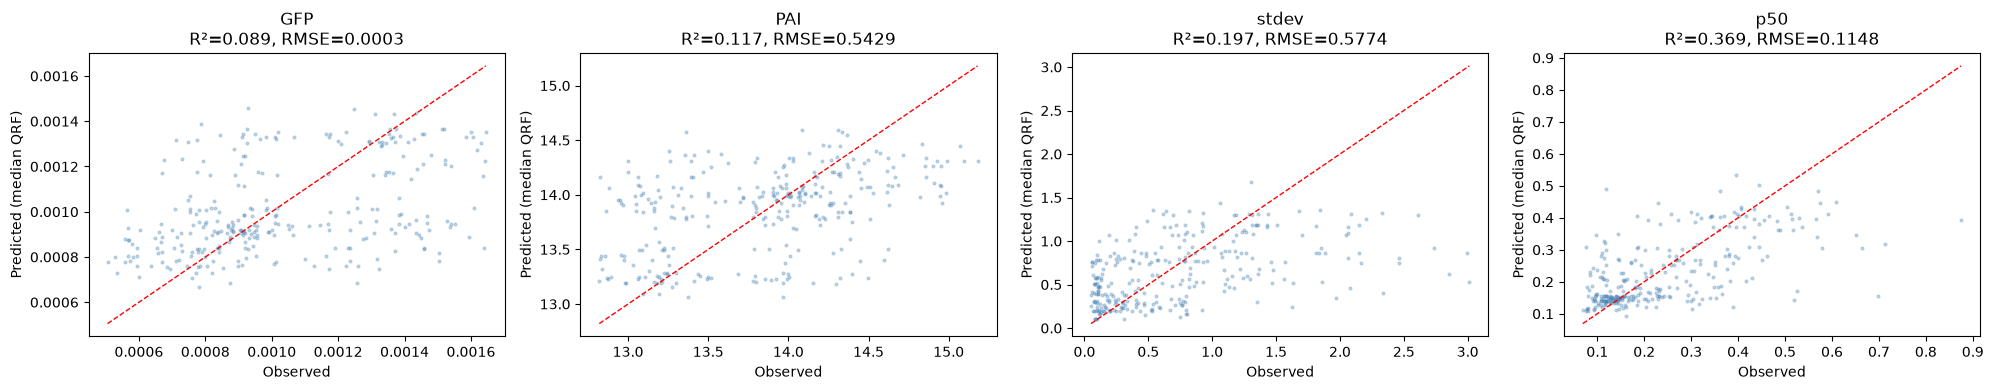

In [7]:
show = [m for m in ['GFP', 'PAI', 'stdev', 'p50'] if m in results]
fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 4))
for ax, m in zip(np.atleast_1d(axes), show):
    obs, pred = results[m]['obs'], results[m]['pred']
    ax.scatter(obs, pred, s=4, alpha=0.3, color='steelblue')
    lo, hi = min(obs.min(), pred.min()), max(obs.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    r2 = results[m]['r2']
    rmse = results[m]['rmse']
    ax.set_title(f'{m}\nR²={r2:.3f}, RMSE={rmse:.4f}')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted (median QRF)')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'fig_obs_vs_pred.png', dpi=150)
plt.show()

## 4.6 Variable importance (permutation, Figure 12 equivalent)

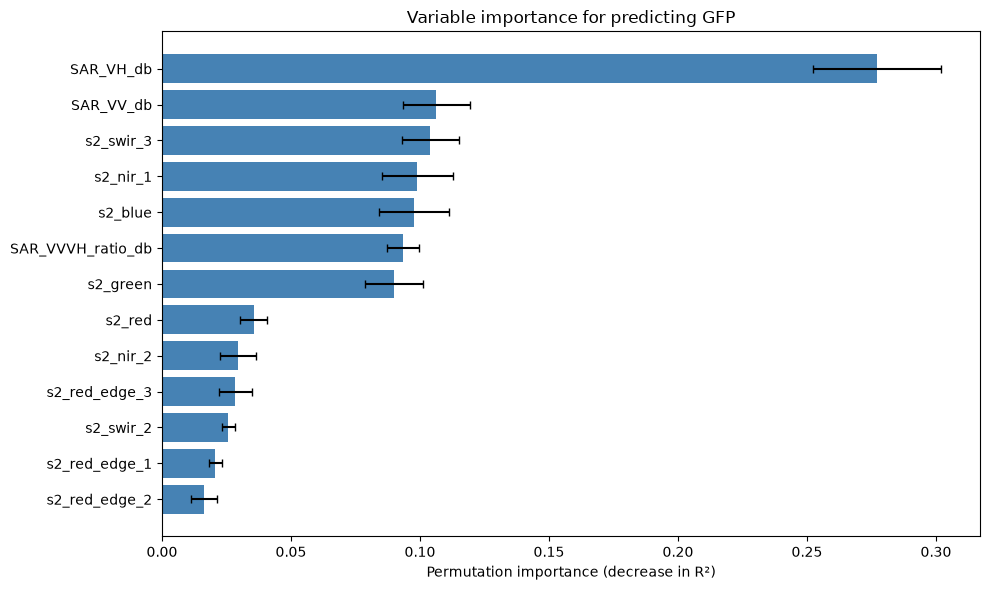

In [8]:
imp_metric = 'GFP'   # change as needed
m_res = results[imp_metric]
model = m_res['model']
valid = ~np.isnan(df[imp_metric].values)
X_v, y_v = X[valid], df[imp_metric].values[valid]

perm = permutation_importance(model, X_v, y_v, n_repeats=10, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({
    'feature': predictor_cols,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'][:20][::-1], imp_df['importance'][:20][::-1],
        xerr=imp_df['std'][:20][::-1], color='steelblue', capsize=3)
ax.set_xlabel('Permutation importance (decrease in R²)')
ax.set_title(f'Variable importance for predicting {imp_metric}')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / f'fig_importance_{imp_metric}.png', dpi=150)
plt.show()

## 4.7 Save trained models

In [10]:
model_dir = config.OUTPUT_DIR / 'models'
model_dir.mkdir(exist_ok=True)
for metric, res in results.items():
    safe_name = metric.replace('>', 'gt').replace('<', 'lt')
    joblib.dump(res['model'], model_dir / f'qrf_{safe_name}.joblib')
print(f"Models saved to {model_dir}")

Models saved to C:\Users\whusg\beetaloo_project\outputs\models
